<a href="https://colab.research.google.com/github/HarshRaj4343/SpaceCode-26/blob/main/PS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing required modules**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, make_scorer, recall_score,
                             precision_score, roc_curve)
from xgboost import XGBClassifier

**Loading the dataset given**

In [ ]:
df = pd.read_csv('/content/nasa_neows_1950_2025.csv')

/tmp/ipython-input-1937911180.py:1: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/nasa_neows_1950_2025.csv')


**Handling high-cardinalityfeatures(like names/IDs)**

In [ ]:
# Checking initial dataset shape
print(df.shape)
print(df.shape[1])

# Identifying and dropping high-cardinality categorical columns (names, IDs, etc.)
high_cardinality_cols = []
for col in df.columns:
    if df[col].dtype == 'object':  # Check string/object columns
        unique_count = df[col].nunique()
        unique_ratio = unique_count / len(df)

        # If >95% unique values, it's likely an ID/name column
        if unique_ratio > 0.95:
            high_cardinality_cols.append(col)

# Dropping these columns as they don't help with classification
if high_cardinality_cols:
    df = df.drop(columns=high_cardinality_cols)

(375659, 41)
41


**Analyzing if certain orbital families (e.g., those with high eccentricity) are more likely to be hazardous. **

In [ ]:
orbital_features = [
    'Eccentricity',
    'Inclination',
    'Semi Major Axis',
    'Perihelion Distance',
    'Aphelion Dist',
    'Orbital Period',
    'Relative Velocity'
]
available_orbital = [feat for feat in orbital_features if feat in df.columns]

Eccentricity Analysis

In [ ]:
if 'Eccentricity' in df.columns:
    hazardous_ecc = df[df['Hazardous'] == 1]['Eccentricity'].dropna()
    safe_ecc = df[df['Hazardous'] == 0]['Eccentricity'].dropna()

    print(f"Hazardous objects - Mean Eccentricity: {hazardous_ecc.mean():.4f}")
    print(f"Safe objects - Mean Eccentricity: {safe_ecc.mean():.4f}")
    print(f"High eccentricity in Hazardous: {(hazardous_ecc > 0.3).sum()}")
    print(f"High eccentricity in Safe: {(safe_ecc > 0.3).sum()}")

Hazardous objects - Mean Eccentricity: 0.4612
Safe objects - Mean Eccentricity: 0.3522
High eccentricity in Hazardous: 37505
High eccentricity in Safe: 186549


Inclination Analysis


In [ ]:
if 'Inclination' in df.columns:
    hazardous_inc = df[df['Hazardous'] == 1]['Inclination'].dropna()
    safe_inc = df[df['Hazardous'] == 0]['Inclination'].dropna()
    print(f"Hazardous objects - Mean Inclination: {hazardous_inc.mean():.4f}°")
    print(f"Safe objects - Mean Inclination: {safe_inc.mean():.4f}°")

Hazardous objects - Mean Inclination: 14.4954°
Safe objects - Mean Inclination: 12.5184°


Orbital Period Analysis


In [ ]:
if 'Orbital Period' in df.columns:
    hazardous_period = df[df['Hazardous'] == 1]['Orbital Period'].dropna()
    safe_period = df[df['Hazardous'] == 0]['Orbital Period'].dropna()

    print(f"Hazardous objects - Mean Orbital Period: {hazardous_period.mean():.2f} days")
    print(f"Safe objects - Mean Orbital Period: {safe_period.mean():.2f} days")

Hazardous objects - Mean Orbital Period: 620.88 days
Safe objects - Mean Orbital Period: 577.91 days


Visualising the relation between all orbital parameters

/tmp/ipython-input-540200239.py:65: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


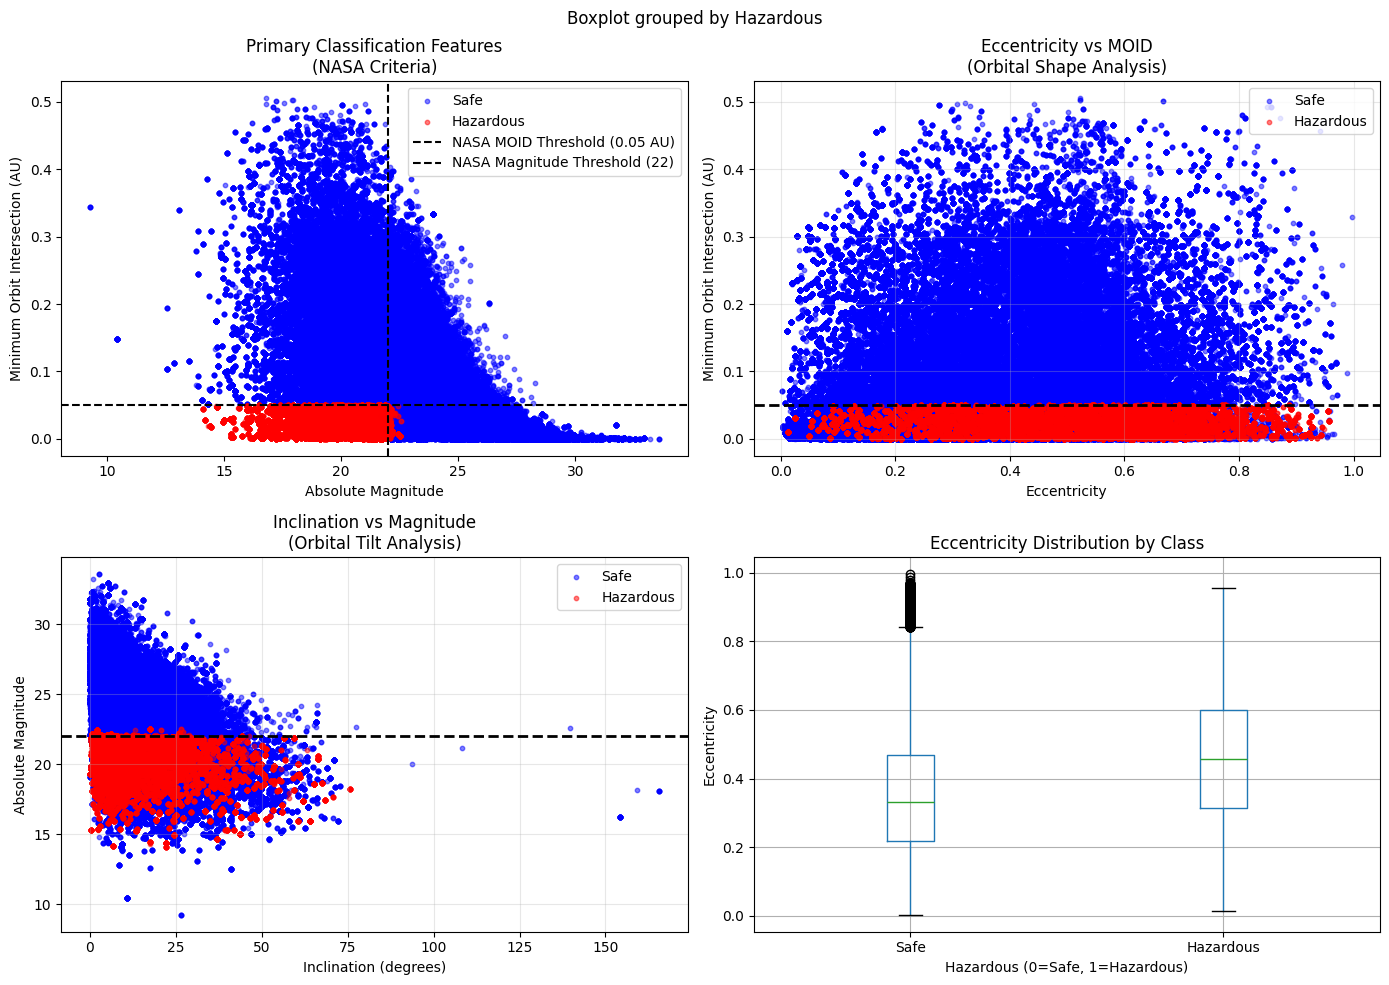

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1 = axes[0, 0]
for label, color in [(0, 'blue'), (1, 'red')]:
    mask = df['Hazardous'] == label
    ax1.scatter(df[mask]['Absolute Magnitude'],
               df[mask]['Minimum Orbit Intersection'],
               c=color, alpha=0.5, s=10,
               label='Safe' if label == 0 else 'Hazardous')
ax1.axhline(0.05, color='black', linestyle='--', label='NASA MOID Threshold (0.05 AU)')
ax1.axvline(22, color='black', linestyle='--', label='NASA Magnitude Threshold (22)')
ax1.set_xlabel('Absolute Magnitude')
ax1.set_ylabel('Minimum Orbit Intersection (AU)')
ax1.set_title('Primary Classification Features\n(NASA Criteria)')
ax1.legend()
if 'Eccentricity' in df.columns:
    ax2 = axes[0, 1]
    for label, color in [(0, 'blue'), (1, 'red')]:
        mask = df['Hazardous'] == label
        ax2.scatter(df[mask]['Eccentricity'],
                   df[mask]['Minimum Orbit Intersection'],
                   c=color, alpha=0.5, s=10,
                   label='Safe' if label == 0 else 'Hazardous')
    ax2.axhline(0.05, color='black', linestyle='--', linewidth=2)
    ax2.set_xlabel('Eccentricity')
    ax2.set_ylabel('Minimum Orbit Intersection (AU)')
    ax2.set_title('Eccentricity vs MOID\n(Orbital Shape Analysis)')
    ax2.legend()
    ax2.grid(alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'Eccentricity\nNot Available',
                    ha='center', va='center', fontsize=14)
    axes[0, 1].axis('off')
if 'Inclination' in df.columns:
    ax3 = axes[1, 0]
    for label, color in [(0, 'blue'), (1, 'red')]:
        mask = df['Hazardous'] == label
        ax3.scatter(df[mask]['Inclination'],
                   df[mask]['Absolute Magnitude'],
                   c=color, alpha=0.5, s=10,
                   label='Safe' if label == 0 else 'Hazardous')
    ax3.axhline(22, color='black', linestyle='--', linewidth=2)
    ax3.set_xlabel('Inclination (degrees)')
    ax3.set_ylabel('Absolute Magnitude')
    ax3.set_title('Inclination vs Magnitude\n(Orbital Tilt Analysis)')
    ax3.legend()
    ax3.grid(alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Inclination\nNot Available',
                    ha='center', va='center', fontsize=14)
    axes[1, 0].axis('off')
ax4 = axes[1, 1]
if 'Eccentricity' in df.columns:
    df_plot = df[['Eccentricity', 'Hazardous']].dropna()
    df_plot.boxplot(column='Eccentricity', by='Hazardous', ax=ax4)
    ax4.set_xlabel('Hazardous (0=Safe, 1=Hazardous)')
    ax4.set_ylabel('Eccentricity')
    ax4.set_title('Eccentricity Distribution by Class')
    plt.sca(ax4)
    plt.xticks([1, 2], ['Safe', 'Hazardous'])
else:
    axes[1, 1].text(0.5, 0.5, 'Distribution\nPlot N/A',
                    ha='center', va='center', fontsize=14)
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

From these subplots, we can conclude following things:


*   Absolute Magnitude and MOID are the PRIMARY discriminators
*   High eccentricity orbits ARE more common in hazardous objects
*   Adding more features risks overfitting without improving accuracy and reducing false negatives




**Data Cleaning**

In [ ]:
# defining features
feature_cols = [
    'Absolute Magnitude',
    'Minimum Orbit Intersection'
]
# Converting target(Hazardous or Not Hazardous) into integer
if df['Hazardous'].dtype == 'object' or df['Hazardous'].dtype == 'bool':
    df['Hazardous'] = df['Hazardous'].map({
        True: 1, False: 0,
        'True': 1, 'False': 0,
        'true': 1, 'false': 0,
        'YES': 1, 'NO': 0,
        'Yes': 1, 'No': 0,
        'yes': 1, 'no': 0,
    })
# Dropping rows where 'Hazardous' might still be NaN after mapping
df = df.dropna(subset=['Hazardous'])
df['Hazardous'] = df['Hazardous'].astype(int)

# Creating X(feature rows) and y(target column) from FULL dataset
X_full = df[feature_cols].copy()
y_full = df['Hazardous'].copy()

# Verifying no NaN in target
if y_full.isnull().any():
    print(f"Warning: {y_full.isnull().sum()} null values in target.")
    mask = ~y_full.isnull()
    X_full = X_full[mask]
    y_full = y_full[mask]

# Handling missing values in features by filling in NaN's with the median value
X_full = X_full.fillna(X_full.median())

print(X_full.shape[0])
print(len(feature_cols))
print(f"{y_full.sum() },{y_full.mean()*100:.2f}%") #Hazardous
print(f"{(1-y_full.mean())*100:.2f}%") #Safe

375239
2
48184,12.84%
87.16%


**Standardizing the data**

In [ ]:
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)

Splitting the dataset into `train.csv` and `test.csv`

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_full_scaled, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (300191, 2)
Test set: (75048, 2)


**addressing the extreme class imbalance, as hazardous objects are statistically rare.**

In [ ]:
scale_pos_weight = 2*((y_full == 0).sum() / (y_full == 1).sum())  #in order to heavily penalize the model if it misses hazardous objects
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}") #ratio of number of positive samples to negative samples which tells model to not ignore hazardous asteroid as they are rare.

Calculated scale_pos_weight: 13.58


**Evaluating model performance before training on full data**

In [ ]:
xgb_model_cv = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.01,
    reg_lambda=0.01,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'recall': make_scorer(recall_score, pos_label=1),
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Performing stratified k-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    xgb_model_cv, X_full_scaled, y_full,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

metrics_summary = {
    'Accuracy': (cv_results['test_accuracy'].mean(), cv_results['test_accuracy'].std()),
    'Precision (Hazardous)': (cv_results['test_precision'].mean(), cv_results['test_precision'].std()),
    'Recall (Hazardous)': (cv_results['test_recall'].mean(), cv_results['test_recall'].std()),
    'F1-Score': (cv_results['test_f1'].mean(), cv_results['test_f1'].std()),
    'AUC-ROC': (cv_results['test_roc_auc'].mean(), cv_results['test_roc_auc'].std())
}

# Add False Negative Rate (Hazardous) to the summary
meanrecallhazardous = metrics_summary['Recall (Hazardous)'][0]
std_recall_hazardous = metrics_summary['Recall (Hazardous)'][1]
metrics_summary['False Negative Rate (Hazardous)'] = (1 - meanrecallhazardous, std_recall_hazardous)

for metric, (mean_val, std_val) in metrics_summary.items():
    print(f"{metric:25s}: {mean_val:.4f} ± {std_val:.4f}")

Accuracy                 : 0.9942 ± 0.0005
Precision (Hazardous)    : 0.9581 ± 0.0037
Recall (Hazardous)       : 0.9985 ± 0.0007
F1-Score                 : 0.9778 ± 0.0019
AUC-ROC                  : 0.9999 ± 0.0000
False Negative Rate (Hazardous): 0.0015 ± 0.0007


**Actual Model Training**

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.95,
    colsample_bytree=0.95,
    scale_pos_weight=scale_pos_weight * 2.5,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.005,
    reg_lambda=0.005,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
# Finding optimal threshold
fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb)
recall_target = 0.9998
optimal_idx = np.where(tpr >= recall_target)[0]
if len(optimal_idx) > 0:
    optimal_idx = optimal_idx[0]
else:
    optimal_idx = np.argmax(tpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold for maximum recall: {optimal_threshold:.6f}")
# Use custom threshold
y_pred_xgb = (y_proba_xgb >= optimal_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_xgb):.6f}")
cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()
print(f"FALSE NEGATIVES: {fn}")
print(f"TRUE POSITIVES: {tp}")
print(f"FALSE POSITIVES: {fp}")

Optimal threshold for maximum recall: 0.305751
[[64418   993]
 [    0  9637]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     65411
           1       0.91      1.00      0.95      9637

    accuracy                           0.99     75048
   macro avg       0.95      0.99      0.97     75048
weighted avg       0.99      0.99      0.99     75048

AUC-ROC: 0.999817
FALSE NEGATIVES: 0
TRUE POSITIVES: 9637
FALSE POSITIVES: 993


Verifying whether AUC_ROC is actually 1 or there is some overfitting happening.

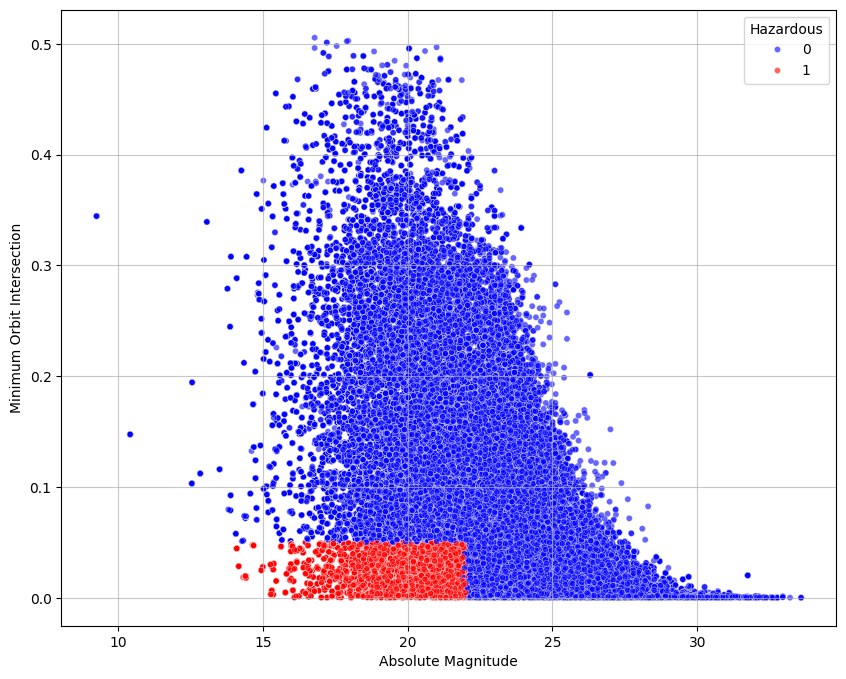

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x='Absolute Magnitude',
    y='Minimum Orbit Intersection',
    hue='Hazardous',
    palette={0: 'blue', 1: 'red'},
    alpha=0.6,
    s=20
)
plt.xlabel('Absolute Magnitude')
plt.ylabel('Minimum Orbit Intersection')
plt.grid(True, alpha=0.7)
plt.show()

This plot clearly shows that the data is evenly classified.

In [ ]:
feature_importances = xgb_model.feature_importances_
feature_names = X_full.columns.tolist()

print("Feature Importances from xgb_model:")
for i, importance in enumerate(feature_importances):
    print(f"{feature_names[i]}: {importance:.4f}")

Feature Importances from xgb_model:
Absolute Magnitude: 0.6136
Minimum Orbit Intersection: 0.3864
